# Text Analytics ML Pipeline - CSI324
## IMDB Sentiment Classification using Text Preprocessing and Naive Bayes

This notebook demonstrates a complete text analytics pipeline covering:
- Text preprocessing (tokenization, stemming, lemmatization)
- Feature engineering using TF-IDF
- Text classification with Naive Bayes
- Model evaluation and deployment preparation

In [91]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import pandas as pd
import numpy as np
import os
import pickle
import joblib

# NLP and Text Processing
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Install missing package if needed
%pip install nltk

# Data manipulation and analysis
import pandas as pd
import numpy as np
import os
import pickle
import joblib

# NLP and Text Processing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Machine Learning - Feature Extraction and Classification
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Machine Learning - Feature Extraction and Classification
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_dat

## Step 1: Load and Explore Dataset
Load the IMDB dataset from the CA2 folder and perform exploratory analysis.

In [92]:
# Load the IMDB dataset
data_path = 'IMDB Dataset.csv'
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few records:")
print(df.head())

Dataset loaded successfully!
Dataset shape: (50000, 2)
Columns: ['review', 'sentiment']

First few records:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [93]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("\nDataset info:")
print(df.info())

# Explore label distribution
print("\nLabel distribution:")
print(df['sentiment'].value_counts())
print("\nLabel distribution (%):")
print(df['sentiment'].value_counts(normalize=True) * 100)

Missing values:
review       0
sentiment    0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Label distribution (%):
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


## Step 2: Text Preprocessing Pipeline
Implement preprocessing steps: lowercasing, tokenization, stopword removal, stemming, and lemmatization

In [94]:
# Initialize preprocessing tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print("Preprocessing tools initialized.")
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print("Preprocessing tools initialized.")

Preprocessing tools initialized.
Preprocessing tools initialized.


In [95]:
# Preprocessing function: Tokenization and Stopword Removal
def preprocess_text_basic(text):
    """
    Basic preprocessing: lowercase, tokenization, stopword removal
    """
    # Convert to lowercase
    text = text.lower()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    
    return tokens

# Preprocessing function: Stemming
def apply_stemming(tokens):
    """
    Apply Porter Stemming to tokens
    """
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens

# Preprocessing function: Lemmatization
def apply_lemmatization(tokens):
    """
    Apply Lemmatization to tokens
    """
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens

# Complete preprocessing pipeline
def preprocess_text(text):
    """
    Complete preprocessing pipeline: tokenization, stopword removal, lemmatization
    """
    # Convert to lowercase
    text = text.lower()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and non-alphabetic tokens
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    
    # Lemmatization
    tokens = apply_lemmatization(tokens)
    
    return ' '.join(tokens)

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [96]:
# Demonstrate preprocessing on sample texts
sample_texts = df['review'].head(3).values

for i, text in enumerate(sample_texts, 1):
    print(f"\n--- Sample {i} ---")
    print(f"Original: {text[:100]}...")
    preprocessed = preprocess_text(text)
    print(f"Preprocessed: {preprocessed[:100]}...")


--- Sample 1 ---
Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The...
Preprocessed: one reviewer mentioned watching oz episode hooked right exactly happened br br first thing struck oz...

--- Sample 2 ---
Original: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-B...
Preprocessed: wonderful little production br br filming technique fashion give comforting sometimes discomforting ...

--- Sample 3 ---
Original: I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air con...
Preprocessed: thought wonderful way spend time hot summer weekend sitting air conditioned theater watching comedy ...


In [97]:
# Apply preprocessing to entire dataset
print("Applying preprocessing to all reviews...")
df['preprocessed_review'] = df['review'].apply(preprocess_text)

# Map sentiment labels to numerical values
df['sentiment_label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"\nPreprocessing complete. Shape: {df.shape}")
print(f"\nSample preprocessed reviews:")
print(df[['review', 'preprocessed_review', 'sentiment_label']].head(3))

Applying preprocessing to all reviews...

Preprocessing complete. Shape: (50000, 4)

Sample preprocessed reviews:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   

                                 preprocessed_review  sentiment_label  
0  one reviewer mentioned watching oz episode hoo...                1  
1  wonderful little production br br filming tech...                1  
2  thought wonderful way spend time hot summer we...                1  


## Step 3: Feature Engineering with TF-IDF
Create TF-IDF vectors from preprocessed text using sklearn's TfidfVectorizer

In [98]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english'
)

print("Creating TF-IDF vectors...")
X_tfidf = tfidf_vectorizer.fit_transform(df['preprocessed_review'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"\nSample feature names: {tfidf_vectorizer.get_feature_names_out()[:10].tolist()}")

Creating TF-IDF vectors...
TF-IDF matrix shape: (50000, 5000)
Number of features: 5000

Sample feature names: ['aaron', 'abandoned', 'abc', 'ability', 'able', 'absence', 'absent', 'absolute', 'absolutely', 'absurd']


In [99]:
# Analyze TF-IDF statistics
print("TF-IDF Statistics:")
print(f"Sparsity: {1.0 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.2%}")
print(f"Mean non-zero values per document: {X_tfidf.nnz / X_tfidf.shape[0]:.2f}")
print(f"Min TF-IDF value: {X_tfidf.min():.4f}")
print(f"Max TF-IDF value: {X_tfidf.max():.4f}")
print(f"Mean TF-IDF value: {X_tfidf.mean():.4f}")

TF-IDF Statistics:
Sparsity: 98.60%
Mean non-zero values per document: 69.85
Min TF-IDF value: 0.0000
Max TF-IDF value: 0.9392
Mean TF-IDF value: 0.0014


## Step 4: Train-Test Split
Divide the dataset into training and testing sets

In [100]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, 
    df['sentiment_label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['sentiment_label']
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Feature dimension: {X_train.shape[1]}")
print(f"\nTraining set label distribution:")
print(f"Positive: {(y_train == 1).sum()}")
print(f"Negative: {(y_train == 0).sum()}")
print(f"\nTesting set label distribution:")
print(f"Positive: {(y_test == 1).sum()}")
print(f"Negative: {(y_test == 0).sum()}")

Training set size: 40000
Testing set size: 10000
Feature dimension: 5000

Training set label distribution:
Positive: 20000
Negative: 20000

Testing set label distribution:
Positive: 5000
Negative: 5000


## Step 5: Train Naive Bayes Classifier
Train a Multinomial Naive Bayes classifier on TF-IDF features

In [101]:
# Train Naive Bayes classifier
print("Training Naive Bayes classifier...")
nb_classifier = MultinomialNB(alpha=1.0)
nb_classifier.fit(X_train, y_train)

print("Model training completed!")
print(f"Number of classes: {len(nb_classifier.classes_)}")
print(f"Class labels: {nb_classifier.classes_}")

Training Naive Bayes classifier...
Model training completed!
Number of classes: 2
Class labels: [0 1]


In [102]:
# Make predictions on training set
y_train_pred = nb_classifier.predict(X_train)

# Calculate training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("Training Set Performance:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1-Score: {train_f1:.4f}")

Training Set Performance:
Accuracy: 0.8605
Precision: 0.8497
Recall: 0.8759
F1-Score: 0.8626


## Step 6: Evaluate Model Performance
Generate predictions and calculate evaluation metrics on test data

In [103]:
# Make predictions on test set
y_test_pred = nb_classifier.predict(X_test)

# Calculate testing metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Testing Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

Testing Set Performance:
Accuracy: 0.8524
Precision: 0.8372
Recall: 0.8750
F1-Score: 0.8557


In [104]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))


Confusion Matrix:
[[4149  851]
 [ 625 4375]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.83      0.85      5000
    Positive       0.84      0.88      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



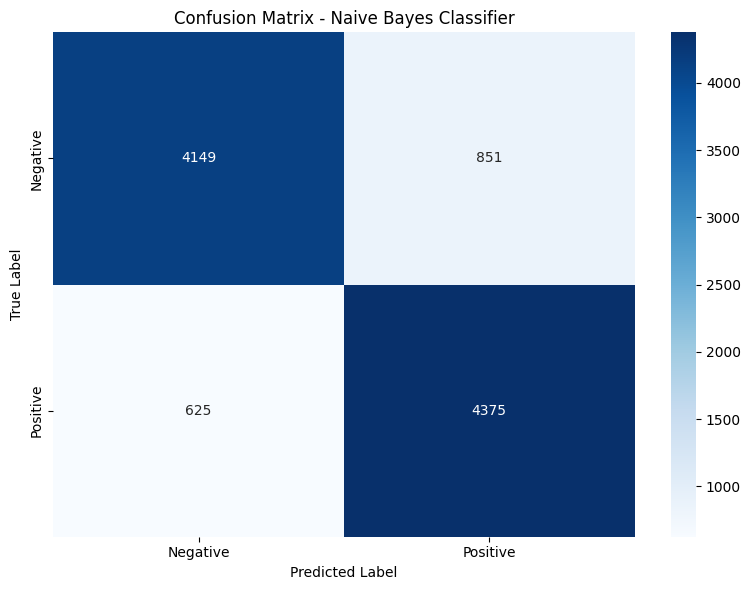

In [105]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Step 7: Save Trained Model and Vectorizer
Serialize the trained Naive Bayes model and TF-IDF vectorizer using pickle

In [106]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained Naive Bayes model
model_path = 'models/naive_bayes_model.pkl'
joblib.dump(nb_classifier, model_path)
print(f"Model saved to {model_path}")

# Save the TF-IDF vectorizer
vectorizer_path = 'models/tfidf_vectorizer.pkl'
joblib.dump(tfidf_vectorizer, vectorizer_path)
print(f"TF-IDF Vectorizer saved to {vectorizer_path}")

print("\nModels and vectorizer saved successfully!")

Model saved to models/naive_bayes_model.pkl
TF-IDF Vectorizer saved to models/tfidf_vectorizer.pkl

Models and vectorizer saved successfully!


## Step 8: Deployment Summary
This pipeline is deployed using Streamlit for interactive sentiment analysis

In [107]:
print("""

DEPLOYMENT INSTRUCTIONS


1. STREAMLIT APP (app.py):
   - Loads the saved models
   - Provides interactive web interface
   - Accepts user input for sentiment prediction
   
2. TO RUN LOCALLY:
   streamlit run app.py
   
3. TO DEPLOY ON STREAMLIT CLOUD:
   - Push code to GitHub
   - Connect repository to Streamlit Cloud
   - App automatically deploys on every push
   
4. FILES REQUIRED FOR DEPLOYMENT:
   - app.py (Streamlit application)
   - requirements.txt (Python dependencies)
   - models/ (directory with .pkl files)
   - README.md (documentation)
   

""")



DEPLOYMENT INSTRUCTIONS


1. STREAMLIT APP (app.py):
   - Loads the saved models
   - Provides interactive web interface
   - Accepts user input for sentiment prediction

2. TO RUN LOCALLY:
   streamlit run app.py

3. TO DEPLOY ON STREAMLIT CLOUD:
   - Push code to GitHub
   - Connect repository to Streamlit Cloud
   - App automatically deploys on every push

4. FILES REQUIRED FOR DEPLOYMENT:
   - app.py (Streamlit application)
   - requirements.txt (Python dependencies)
   - models/ (directory with .pkl files)
   - README.md (documentation)



